# MUSIC GENRE CLASSIFICATION

## Chuẩn bị dữ liệu

### Khai báo thư viện

In [27]:
import os, sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
    
from IPython import display
import warnings
warnings.filterwarnings('ignore')

### Khai báo các tham số

In [6]:
params_cfg = {
    'seed': 42,
    'exps_dir': '../../exps',
    'exp_name': 'music_genre_baseline',
    'data_dir': '../../data/music-genre',
    'verbose': False,
    'k_folds': 5
}

params_cfg.update(**{'save_dir': os.path.abspath(f'{params_cfg["exps_dir"]}/{params_cfg["exp_name"]}')})

for v in params_cfg:
    print(f'+ {v}: {params_cfg[v]}')

+ seed: 42
+ exps_dir: ../../exps
+ exp_name: music_genre_baseline
+ data_dir: ../../data/music-genre
+ verbose: False
+ k_folds: 5
+ save_dir: d:\Data\Code\Python\ML WS\exps\music_genre_baseline


### Tải dữ liệu train, test

In [7]:
df_train = pd.read_csv(f'{params_cfg['data_dir']}/train (1).csv')
df_test = pd.read_csv(f'{params_cfg['data_dir']}/test (2).csv')

display.display(df_train.head())
display.display(df_test.head())

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),NaN,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
1,14398,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
2,14399,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,NaN,0.1140,0.298,103.971,232533.0,4
3,14400,WALK THE MOON,Different Colors,52.0,0.480,0.826,NaN,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
4,14401,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,NaN,0.0672,0.805,76.030,118439.0,4


## Preprocessing

In [ ]:
def preprocess_data(df, is_train=True, is_debug=False, **kwargs):
    """
    Tiền xử lý dữ liệu cho bài toán dự đoán thể loại bài hát.
    
    Parameters:
    - df: DataFrame đầu vào
    - is_train: True nếu là training data (có cột Class), False nếu là test data
    - is_debug: True để in thông tin debug
    """
    
    # Tạo bản copy để không ảnh hưởng đến dataframe gốc
    df_output = df.copy()
    
    # Tách features và target (nếu là training data)
    if is_train:
        X = df_output.drop('Class', axis=1)
        y = df_output['Class']
    else:
        X = df_output
    
    # Phân loại columns
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    if is_debug:
        print(f"Numerical features: {len(numeric_features)}")
        print(f"Categorical features: {len(categorical_features)}")
        print(f"Total features: {len(numeric_features) + len(categorical_features)}")

    # Xử lý missing values cho numerical features
    for col in numeric_features:
        if df_output[col].isnull().any():
            if is_debug:
                print(f"Filling missing values in numerical column: {col}")
            df_output[col] = df_output[col].fillna(df_output[col].median())

    # Drop các cột categorical
    df_output = df_output.drop(columns=categorical_features)
    df_output = df_output.drop(columns=['Id'], errors='ignore')  # Drop cột Id nếu có
    # Thêm cột target trở lại nếu là training data
    if is_train:
        df_output['Class'] = y

    if is_debug:
        print(f"Missing values after preprocessing: {df_output.isnull().sum().sum()}")
        print(f"Final shape: {df_output.shape}")

    return df_output

In [23]:
print("\nPreprocessing training data...")
print("----------------------------")
df_train_processed = preprocess_data(df_train, is_train=True, is_debug=False)
print("\nPreprocessing test data...")
print("----------------------------")
df_test_processed = preprocess_data(df_test, is_train=False, is_debug=False)


Preprocessing training data...
----------------------------

Preprocessing test data...
----------------------------


## Model training

### Baseline

In [28]:
numeric_features = df_train_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_train_processed.select_dtypes(include=['object', 'category']).columns.tolist()

base_models = {
    'CatBoost': CatBoostClassifier(random_state=params_cfg['seed'], verbose=False, allow_writing_files=False, train_dir=None),
    'LightGBM': LGBMClassifier(random_state=params_cfg['seed'], verbose=-1),
    'XGBoost': XGBClassifier(random_state=params_cfg['seed']),
    'Random Forest': RandomForestClassifier(random_state=params_cfg['seed']),
    'Extra Trees': ExtraTreesClassifier(random_state=params_cfg['seed']),
}

In [24]:
df_train_processed.isna().sum()

Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64

In [30]:
results = []
names = []

for name, model in base_models.items():
    # Dùng StratifiedKFold để đảm bảo tỉ lệ Class đều nhau ở các fold
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=params_cfg['seed'])
    
    pipeline = Pipeline(steps=[
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    # Tính điểm
    cv_results = cross_val_score(pipeline, df_train_processed.drop('Class', axis=1), df_train_processed['Class'], cv=kfold, scoring='accuracy')
    
    results.append(cv_results)
    names.append(name)
    print(f"{name}: Mean Accuracy = {cv_results.mean():.4f} (Std: {cv_results.std():.4f})")

CatBoost: Mean Accuracy = 0.5270 (Std: 0.0050)
LightGBM: Mean Accuracy = 0.5191 (Std: 0.0067)
XGBoost: Mean Accuracy = 0.5107 (Std: 0.0063)
Random Forest: Mean Accuracy = 0.5069 (Std: 0.0086)
Extra Trees: Mean Accuracy = 0.4992 (Std: 0.0064)


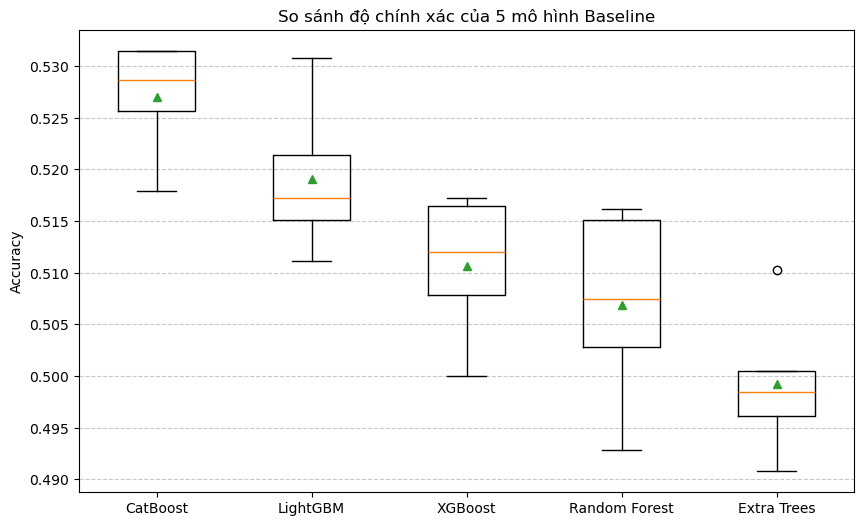

In [31]:
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names, showmeans=True)
plt.title('So sánh độ chính xác của 5 mô hình Baseline')
plt.ylabel('Accuracy')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

### Tuning

In [ ]:
param_distributions = {
    'CatBoost': {
        'iterations': randint(100, 1000),           # Số lượng cây
        'depth': randint(4, 10),                    # Độ sâu của cây (CatBoost nhạy cảm với cái này)
        'learning_rate': uniform(0.01, 0.2),        # Tốc độ học (0.01 đến 0.21)
        'l2_leaf_reg': randint(1, 10),              # Regularization (chống overfitting)
        'border_count': randint(32, 255)            # Số lượng điểm cắt cho biến số
    },
    'LightGBM': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.2),
        'num_leaves': randint(20, 150),             # Quan trọng nhất của LightGBM
        'max_depth': randint(5, 15),                # Giới hạn độ sâu để tránh overfitting
        'min_child_samples': randint(10, 100),      # Số lượng mẫu tối thiểu trong 1 lá
        'subsample': uniform(0.6, 0.4),             # Lấy mẫu dòng (0.6 đến 1.0)
        'colsample_bytree': uniform(0.6, 0.4)       # Lấy mẫu cột
    },
    'XGBoost': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.2),
        'max_depth': randint(3, 10),
        'min_child_weight': randint(1, 10),         # Kiểm soát việc chia nhánh
        'gamma': uniform(0, 5),                     # Giảm loss tối thiểu để chia nhánh
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4)
    },
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': [None] + list(range(10, 50)),  # None hoặc độ sâu cụ thể
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    },
    'Extra Trees': {
        'n_estimators': randint(100, 500),
        'max_depth': [None] + list(range(10, 50)),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }
}

In [34]:
best_estimators = {}
results_tuning = {}

for model_name in base_models.keys():
    print(f"\nTuning {model_name}...")
    
    # Lấy model và param grid
    model = base_models[model_name]
    param_grid = param_distributions[model_name]
    
    # Tạo pipeline
    pipeline = Pipeline(steps=[
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    param_grid_prefixed = {f"model__{k}": v for k, v in param_grid.items()}
    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        pipeline,
        param_grid_prefixed,
        n_iter=20,
        cv=3,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    
    # Fit toàn bộ data
    X = df_train_processed.drop('Class', axis=1)
    y = df_train_processed['Class']
    
    random_search.fit(X, y)
    
    # In kết quả
    best_accuracy = random_search.best_score_
    print(f"- Best Accuracy: {best_accuracy:.4f}")
    print(f"- Best params: {random_search.best_params_}")

    # Lưu kết quả
    results_tuning[model_name] = best_accuracy
    best_estimators[model_name] = random_search.best_estimator_


Tuning CatBoost...
- Best Accuracy: 0.5458
- Best params: {'model__border_count': 193, 'model__depth': 5, 'model__iterations': 369, 'model__l2_leaf_reg': 8, 'model__learning_rate': 0.12408879488107988}

Tuning LightGBM...
- Best Accuracy: 0.5172
- Best params: {'model__colsample_bytree': 0.8650089137415928, 'model__learning_rate': 0.07234221521788219, 'model__max_depth': 10, 'model__min_child_samples': 63, 'model__n_estimators': 205, 'model__num_leaves': 23, 'model__subsample': 0.6739417822102108}

Tuning XGBoost...
- Best Accuracy: 0.5463
- Best params: {'model__colsample_bytree': 0.908897907718663, 'model__gamma': 0.993578407670862, 'model__learning_rate': 0.01110442342472048, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 692, 'model__subsample': 0.88453678109946}

Tuning Random Forest...
- Best Accuracy: 0.5362
- Best params: {'model__bootstrap': True, 'model__max_depth': 47, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samp

In [35]:
os.makedirs(params_cfg['save_dir'], exist_ok=True)

# Lưu models
for model_name, model in best_estimators.items():
    filename = f"{model_name.replace(' ', '_').lower()}_best_model.pkl"
    filepath = os.path.join(params_cfg['save_dir'], filename)
    joblib.dump(model, filepath)
    print(f"Saved: {filename}")

Saved: catboost_best_model.pkl
Saved: lightgbm_best_model.pkl
Saved: xgboost_best_model.pkl
Saved: random_forest_best_model.pkl
Saved: extra_trees_best_model.pkl


In [36]:
# Hiển thị ranking tất cả models
print("\nMODEL RANKING:")
for model_name, accuracy in sorted(results_tuning.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:20}: {accuracy:.4f}")


MODEL RANKING:
XGBoost             : 0.5463
CatBoost            : 0.5458
Random Forest       : 0.5362
Extra Trees         : 0.5283
LightGBM            : 0.5172


In [41]:
df_train_processed.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,0.00392,0.106,0.235,152.429,204947.0,4,9
1,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.04680,0.104,0.380,132.921,191956.0,4,6
2,44.0,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.63500,0.284,0.635,159.953,161037.0,4,10
3,12.0,0.515,0.308,6.0,-14.711,1,0.0312,0.907000,0.02130,0.300,0.501,172.472,298093.0,3,2
4,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,0.00392,0.211,0.619,88.311,254145.0,4,5


In [42]:
df_test_processed.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,44.0,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
1,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
2,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,0.003755,0.1140,0.298,103.971,232533.0,4
3,52.0,0.480,0.826,6.0,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
4,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,0.003755,0.0672,0.805,76.030,118439.0,4


## Submit

In [48]:
X_train = df_train_processed.drop('Class', axis=1)
y_train = df_train_processed['Class']

for model_name in ['XGBoost', 'CatBoost', 'Random Forest']:
    
    best_estimators[model_name].fit(X_train, y_train)

    preds = best_estimators[model_name].predict(df_test_processed)
    preds = np.asarray(preds)
    # Nếu là proba (2D, >1 col) -> argmax
    if preds.ndim == 2 and preds.shape[1] > 1:
        preds = preds.argmax(axis=1)
    # Nếu là (n,1) -> flatten
    elif preds.ndim == 2 and preds.shape[1] == 1:
        preds = preds.ravel()
    df_submission = pd.DataFrame({
        'Id': df_test['Id'],
        'Class': preds
    })

    df_submission.to_csv(f"{params_cfg['save_dir']}/submission_{model_name.replace(' ', '_').lower()}.csv", index=False)